Import Libraries

In [1]:
import sys
import joblib
import pandas as pd

sys.path.append("..")

from src.data import load_and_clean_data
from src.train import prepare_data
from src.evaluate import (
    evaluate_model,
    print_classification_report,
    plot_confusion_matrix,
    plot_roc_curves
)

Load and Clean Data

In [2]:
df = load_and_clean_data()

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Prepare Testing/Validation Data

In [3]:
X_train, X_test, y_train, y_test = prepare_data(
    df
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (5625, 19)
Testing shape: (1407, 19)


Load the Trained Models

In [4]:
logistic_model = joblib.load(
    "../models/logistic_regression.joblib"
)

random_forest_model = joblib.load(
    "../models/random_forest.joblib"
)

print("Models loaded.")

Models loaded.


Evaluate Logistic Regression Model

In [5]:
logistic_results = evaluate_model(
    logistic_model,
    X_test,
    y_test
)

logistic_results

{'Accuracy': 0.8038379530916845,
 'Precision': 0.6484848484848484,
 'Recall': 0.5721925133689839,
 'F1 Score': 0.6079545454545454,
 'ROC-AUC': 0.8359290473207676}

Evaluate Random Forest Model

In [6]:
random_forest_results = evaluate_model(
    random_forest_model,
    X_test,
    y_test
)

random_forest_results

{'Accuracy': 0.7896233120113717,
 'Precision': 0.6344827586206897,
 'Recall': 0.4919786096256685,
 'F1 Score': 0.5542168674698795,
 'ROC-AUC': 0.8139989957084653}

Compare Both Models

In [7]:
results = pd.DataFrame({
    "Logistic Regression": logistic_results,
    "Random Forest": random_forest_results
})

results

,Logistic Regression,Random Forest
Accuracy,0.803838,0.789623
Precision,0.648485,0.634483
Recall,0.572193,0.491979
F1 Score,0.607955,0.554217
ROC-AUC,0.835929,0.813999


Transpose Results DataFrame for Readability

In [8]:
results = results.T

results

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.803838,0.648485,0.572193,0.607955,0.835929
Random Forest,0.789623,0.634483,0.491979,0.554217,0.813999


Generate Classification Report (Logistic Regression)

In [9]:
print("Logistic Regression Classification Report:")

print_classification_report(
    logistic_model,
    X_test,
    y_test
)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



Generate Classification Report (Random Forest)

In [10]:
print("Random Forest Classification Report:")

print_classification_report(
    random_forest_model,
    X_test,
    y_test
)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Generate Confusion Matrix (Logistic Regression)

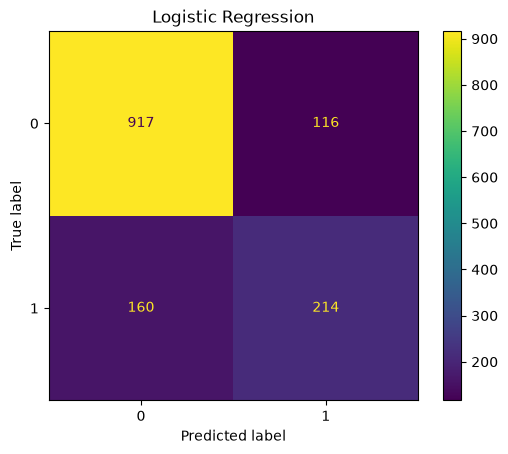

In [11]:
plot_confusion_matrix(
    logistic_model,
    X_test,
    y_test,
    "Logistic Regression"
)

Generate Confusion Matrix (Random Forest)

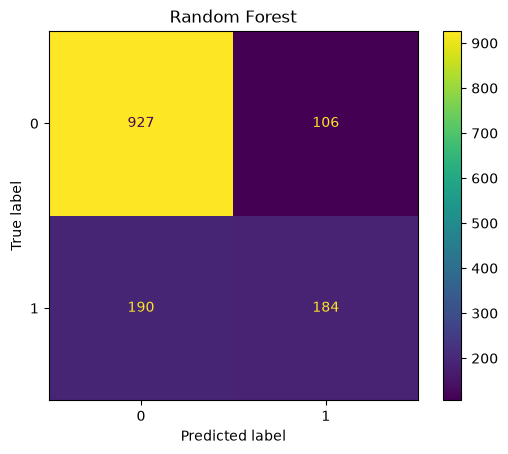

In [12]:
plot_confusion_matrix(
    random_forest_model,
    X_test,
    y_test,
    "Random Forest"
)

Generate Receiver Operating Characteristic (ROC) Curves

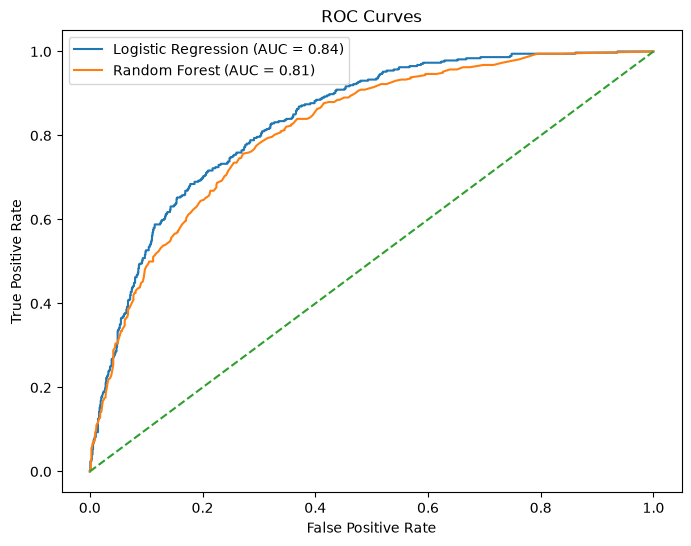

In [13]:
plot_roc_curves(
    logistic_model,
    random_forest_model,
    X_test,
    y_test
)

Determine Best Model using F1

In [14]:
best_model_name = results["F1 Score"].idxmax()

print(
    "Best model based on F1 Score:",
    best_model_name
)

Best model based on F1 Score: Logistic Regression


Select the Best Model

In [15]:
if best_model_name == "Logistic Regression":
    best_model = logistic_model
else:
    best_model = random_forest_model

Save the Best Model

In [16]:
joblib.dump(
    best_model,
    "../models/churn_model.joblib"
)

print("Best model saved as churn_model.joblib")

Best model saved as churn_model.joblib
